# BÀI TẬP 5.3 Gom cụm DBSCAN trên tập dữ liệu "UCI - Wholesale customers"

---

**Họ và tên:** Nguyễn Quang Linh
**MSSV:** 038205003016

---

#### Tải dữ liệu từ trang http://archive.ics.uci.edu/ml/datasets/wholesale+customers
- Nạp dữ liệu lên bộ nhớ, xóa tất cả các thuộc tính, chỉ để hai thuộc tính Fresh và Milk.

In [7]:
import pandas as pd
column_names = ['Fresh','Milk']
df = pd.read_csv('../../data/Elearning05/Wholesale_customers_data.csv')
print(df.head())

   Fresh  Milk
0  12669  9656
1   7057  9810
2   6353  8808
3  13265  1196
4  22615  5410


- Chuẩn hóa các giá trị thuộc tính về [0,1]

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_scaled =  scaler.fit_transform(df)

df_scaled = pd.DataFrame(x_scaled, columns=df.columns)
# Sau khi chuẩn hóa range [0,1] 
print(df_scaled.head())

      Fresh      Milk
0  0.052933  0.523568
1 -0.391302  0.544458
2 -0.447029  0.408538
3  0.100111 -0.624020
4  0.840239 -0.052396


- Gom cụm các đối tượng khách hàng dùng DBSCAN, với MinPTs = 5, Epsilon canh chỉnh cho phù hợp.

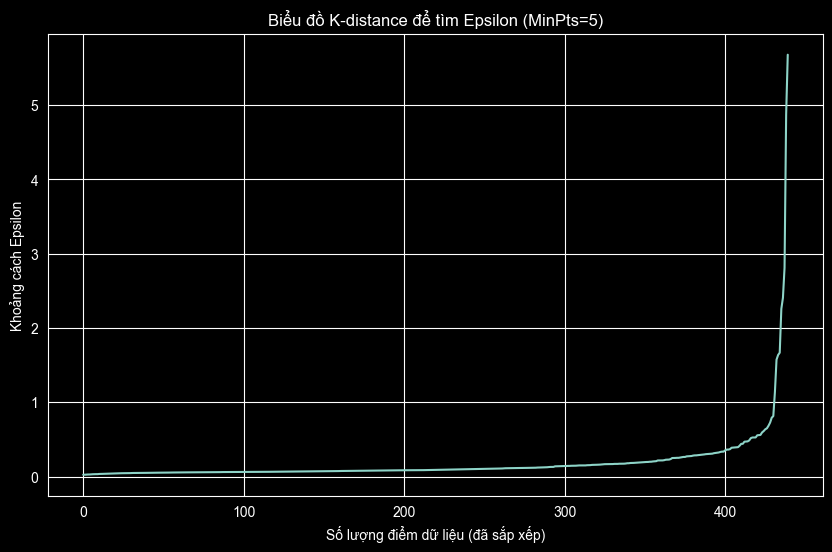

In [28]:
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import numpy as np

neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(x_scaled)
distances, indices = neighbors_fit.kneighbors(x_scaled)

distances = np.sort(distances[:, 4], axis=0)

plt.figure(figsize=(10, 6))
plt.plot(distances)
plt.title('Biểu đồ K-distance để tìm Epsilon (MinPts=5)')
plt.xlabel('Số lượng điểm dữ liệu (đã sắp xếp)')
plt.ylabel('Khoảng cách Epsilon')
plt.grid(True)
plt.show()

- Plot dữ liệu với thông tin các cụm

Thống kê số điểm trong các cụm:
Cluster_DBSCAN
 0    431
-1      9
Name: count, dtype: int64


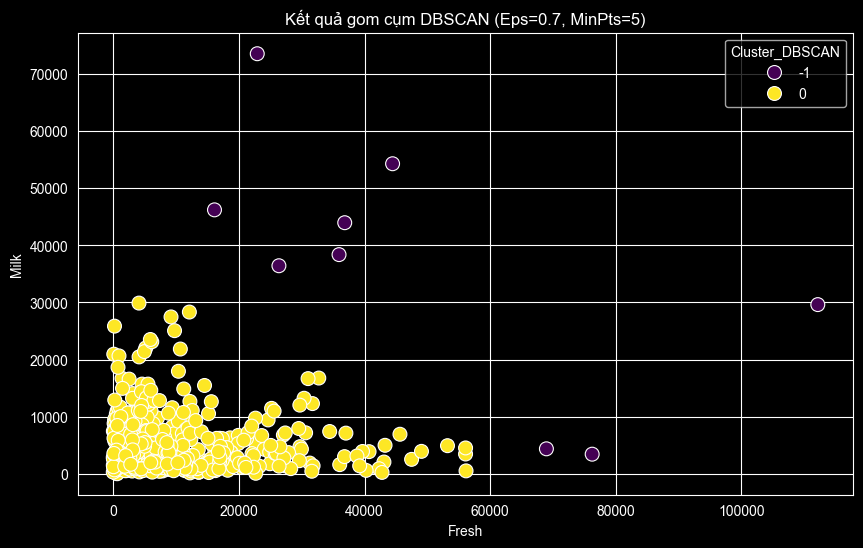

In [33]:
from sklearn.cluster import DBSCAN
import seaborn as sns
# eps tầm 0.5 đến 0.7 như cái chỗ khủy tay ở trên
eps = 0.7
min_pts = 5

dbscan = DBSCAN(eps=eps, min_samples=min_pts)
labels = dbscan.fit_predict(x_scaled)

df['Cluster_DBSCAN'] = labels

print("Thống kê số điểm trong các cụm:")
print(df['Cluster_DBSCAN'].value_counts())

# Dùng seaborn để visualize
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Fresh', y='Milk', hue='Cluster_DBSCAN', palette='viridis', s=100)

plt.title(f'Kết quả gom cụm DBSCAN (Eps={eps}, MinPts={min_pts})')
plt.show()
